[Agent 3 Lesson](https://youtu.be/jGg_1h0qzaM?t=7432) - React Agent (Reasonning and Acting)

Introducing calling tools

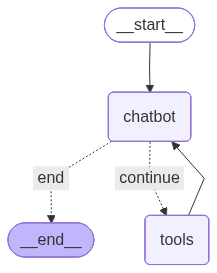

In [16]:
from typing import Annotated, Sequence, TypedDict

from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    

@tool
def add(a:int, b: int) -> int:
    """ Addition function which adds 2 number together and returns the result """
    
    return a + b
    

@tool
def subtract(a:int, b: int) -> int:
    """ Subtraction function which subtracts 2 numbers and returns the result """
    
    return a - b
    

@tool
def multiply(a:int, b: int) -> int:
    """ Multiplication function which multiplies 2 numbers together and returns the result """
    
    return a * b


tools = [add, subtract, multiply]    
ollama = ChatOllama(model="llama3.1:8b", temperature=0.5, host="http://localhost:11434").bind_tools(tools)


def chat_node(state: State) -> State:
    system_message = SystemMessage(content=
        "You are a friendly assistant yet provide factual and short responses."
    )
    return {"messages": [ollama.invoke([system_message] + state["messages"])]}

def should_continue(state: State) -> str:
    last_message = state["messages"][-1]
    print("Last message:", last_message)
    if not last_message.tool_calls:       # there are more tool calls needed
        return "end"
    return "continue"


graph = StateGraph(State)
graph.add_node("tools", ToolNode(tools=tools))
graph.add_node("chatbot", chat_node)
graph.add_edge(START, "chatbot")
graph.add_conditional_edges(
    "chatbot", 
    should_continue, 
    {
        "continue": "tools", 
        "end": END
    }
)
graph.add_edge("tools", "chatbot")

worflow = graph.compile()
display(Image(worflow.get_graph().draw_mermaid_png()))

In [17]:
state = {"messages": [HumanMessage(content="Add 3 and 6. multiply 5 and 10. show the result of each operation")]}
# result = worflow.invoke(state)
# print(result["messages"][-1].content) # [-1] gets the last item in the list

result = worflow.stream(state, stream_mode="values")
for s in result:
    message = s["messages"][-1]
    if isinstance(message, tuple):
        print(message)
    else:
        message.pretty_print()


================================ Human Message =================================

Add 3 and 6. multiply 5 and 10. show the result of each operation
Last message: content='' additional_kwargs={} response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-02-22T23:10:43.551390975Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6428934006, 'load_duration': 25520540, 'prompt_eval_count': 326, 'prompt_eval_duration': 1163499157, 'eval_count': 43, 'eval_duration': 5237123653, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'} id='lc_run--019c879e-81f5-7e22-8383-03a2eb9226e4-0' tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 6}, 'id': 'cf830f91-4cde-4899-9cc1-4993f5577318', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 5, 'b': 10}, 'id': '7710e14f-dbd7-4b6f-95d5-7a43c432f0b8', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 326, 'output_tokens': 43, 'total_tokens': 369}
================================== Ai Message 